In [1]:
# Cell 1: Environment Setup & GPU Verification
import torch
import os

# Verify GPU
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"✅ GPU Detected: {gpu_name}")
    if "T4" not in gpu_name:
        print("⚠️ Warning: You are not running on a T4. Go to Runtime > Change runtime type > T4 GPU.")
else:
    raise RuntimeError("❌ No GPU found. Please enable GPU in Runtime > Change runtime type.")

# Install Ultralytics (YOLO11 support)
# We install onnx/onnxruntime-gpu for the export step later
%pip install ultralytics onnx onnxruntime-gpu
from ultralytics import YOLO
from IPython import display
display.clear_output()

import ultralytics
print(f"✅ Ultralytics version: {ultralytics.__version__}")
print("✅ Environment ready.")

✅ Ultralytics version: 8.3.249
✅ Environment ready.


In [2]:
# Cell 2: Mount Drive, Define Paths, & Extract Dataset
from google.colab import drive
import os
import zipfile
import shutil

# 1. Mount Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Define Paths
# Pastikan nama file ZIP di drive Anda BENAR-BENAR sesuai dengan ini
zip_filename = 'Letuce_Disease.v1i.yolov11.zip'
zip_path = f'/content/drive/MyDrive/klasifikasi_penyakit/{zip_filename}'

project_root = '/content/final_project'
dataset_path = os.path.join(project_root, 'dataset')
output_path = os.path.join(project_root, 'output')

# 3. Create Directory Structure
subfolders = ['checkpoints', 'logs', 'plots', 'evaluation', 'inference']
for folder in subfolders:
    os.makedirs(os.path.join(output_path, folder), exist_ok=True)
    print(f"Created/Verified folder: {os.path.join(output_path, folder)}")

# 4. Extract Dataset
if not os.path.exists(zip_path):
    raise FileNotFoundError(f"❌ File ZIP tidak ditemukan di: {zip_path}\nMohon cek kembali path di Google Drive Anda.")

if not os.path.exists(dataset_path):
    print(f"Extracting dataset to {dataset_path}...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_path)
        print("✅ Extraction Complete.")
    except zipfile.BadZipFile:
        print("❌ File ZIP rusak atau korup.")
else:
    print("✅ Dataset already extracted. Skipping extraction.")

# 5. Install Dependencies (Optional specific libs)
!pip install -q pycocotools
print("✅ Environment & Data Ready.")

Mounting Google Drive...
Mounted at /content/drive
Created/Verified folder: /content/final_project/output/checkpoints
Created/Verified folder: /content/final_project/output/logs
Created/Verified folder: /content/final_project/output/plots
Created/Verified folder: /content/final_project/output/evaluation
Created/Verified folder: /content/final_project/output/inference
Extracting dataset to /content/final_project/dataset...
✅ Extraction Complete.
✅ Environment & Data Ready.


In [3]:
# Cell 3: Validate Config & Fix Paths
import yaml
import glob

# Cari file data.yaml di dalam folder hasil ekstrak
yaml_files = glob.glob(os.path.join(dataset_path, '*.yaml')) + glob.glob(os.path.join(dataset_path, '*.yml'))

if not yaml_files:
    # Coba cari di subfolder jika struktur ZIP-nya nested (misal: dataset/dataset/data.yaml)
    yaml_files = glob.glob(os.path.join(dataset_path, '*', '*.yaml'))
    if not yaml_files:
        raise FileNotFoundError(f"❌ Tidak ditemukan file .yaml di {dataset_path}")

yaml_path = yaml_files[0]
print(f"Found config: {yaml_path}")

# Load dan perbaiki path di dalam YAML agar absolut
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Update path agar sesuai dengan environment Colab saat ini
data_config['path'] = os.path.dirname(yaml_path) # Set root ke folder di mana yaml berada
data_config['train'] = 'train/images'
data_config['val'] = 'valid/images'
data_config['test'] = 'test/images' # Asumsi folder test ada

# Save kembali
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print(f"✅ YAML Configured correctly at: {yaml_path}")
print(f"Classes: {data_config.get('names')}")

Found config: /content/final_project/dataset/data.yaml
✅ YAML Configured correctly at: /content/final_project/dataset/data.yaml
Classes: ['Bacterial', 'Downy_mildew_on_lettuce', 'Powdery_mildew_on_lettuce', 'Septoria_Blight_on_lettuce', 'Viral', 'Wilt_and_leaf_blight_on_lettuce', 'healthy']


In [4]:
# Cell 4: Train YOLO11n with Custom Output Path
from ultralytics import YOLO

model = YOLO('yolo11n.pt')  # Load pretrained YOLO11 Nano

print(f"🚀 Starting Training... Saving to {output_path}")

results = model.train(
    data=yaml_path,
    epochs=50,
    patience=20,
    imgsz=640,
    batch=32,
    device=0,
    # Mengarahkan output ke folder yang sudah Anda siapkan
    project=output_path,
    name='lettuce_yolo11_run',
    exist_ok=True,
    plots=True,
    verbose=True
)

print("✅ Training Complete.")

🚀 Starting Training... Saving to /content/final_project/output
Ultralytics 8.3.249 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=lettuce_yolo11_run, nbs=64, nms=False, opset=None, optimize=False, 


📊 Final Performance Summary (Epoch 50):
mAP@0.5:       0.9915
mAP@0.5:0.95:  0.9120
Precision:     0.9734
Recall:        0.9731

✅ Confusion Matrix (Normalized):


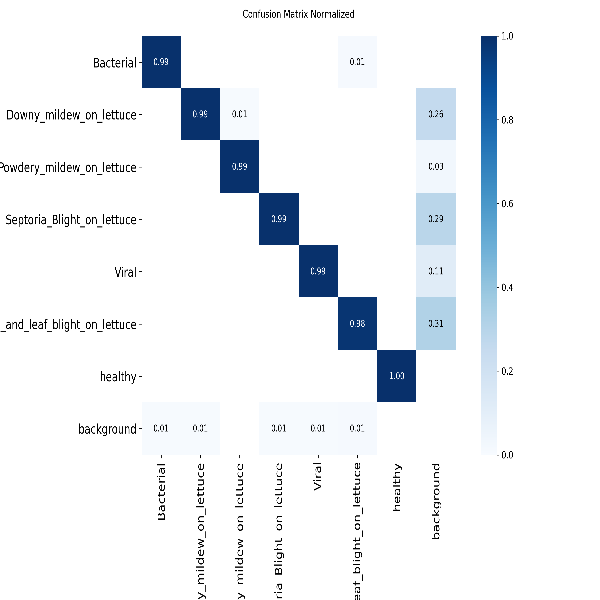


----------------------------------------

✅ Confusion Matrix (Absolute Counts):


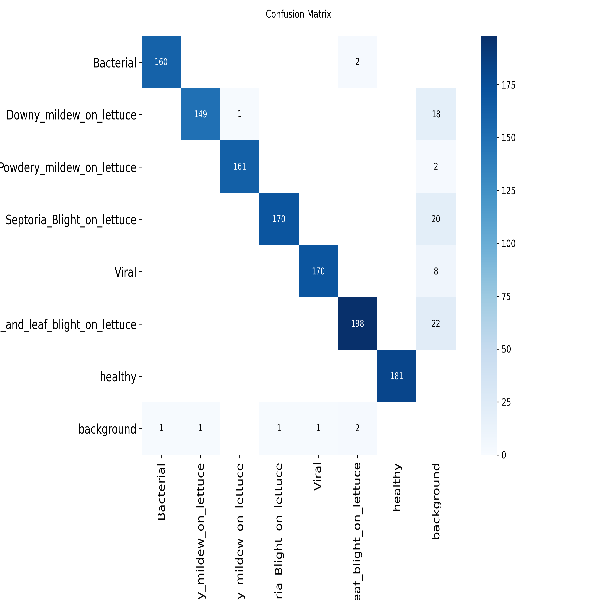

In [8]:
# Cell 5: Performance Analysis (Fixed Path & Added Non-Normalized Matrix)
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from google.colab.patches import cv2_imshow

# 1. Tentukan Path yang Benar (Sesuai output Cell 4)
# Kita menggunakan path dari 'output_path' + 'name' yang diset di Cell 4
base_result_path = '/content/final_project/output/lettuce_yolo11_run'
log_path = os.path.join(base_result_path, 'results.csv')

# Cek apakah file ada sebelum membaca
if not os.path.exists(log_path):
    print(f"❌ File tidak ditemukan di: {log_path}")
    print("Isi folder output saat ini:")
    print(os.listdir(os.path.dirname(base_result_path))) # Cek parent folder
else:
    # 2. Load Training Logs
    df = pd.read_csv(log_path)
    df.columns = [x.strip() for x in df.columns]

    # Print Final Metrics
    final_epoch = df.iloc[-1]
    print(f"\n📊 Final Performance Summary (Epoch {len(df)}):")
    print(f"mAP@0.5:       {final_epoch['metrics/mAP50(B)']:.4f}")
    print(f"mAP@0.5:0.95:  {final_epoch['metrics/mAP50-95(B)']:.4f}")
    print(f"Precision:     {final_epoch['metrics/precision(B)']:.4f}")
    print(f"Recall:        {final_epoch['metrics/recall(B)']:.4f}")

    # 3. Display Confusion Matrices
    print("\n" + "="*40)

    # Path gambar
    norm_matrix_path = os.path.join(base_result_path, 'confusion_matrix_normalized.png')
    raw_matrix_path = os.path.join(base_result_path, 'confusion_matrix.png')

    # Tampilkan Normalized
    if os.path.exists(norm_matrix_path):
        print("✅ Confusion Matrix (Normalized):")
        img_norm = cv2.imread(norm_matrix_path)
        cv2_imshow(cv2.resize(img_norm, (600, 600)))
    else:
        print("⚠️ Normalized Confusion Matrix belum terbentuk.")

    print("\n" + "-"*40 + "\n")

    # Tampilkan RAW (Tidak Normalize) -> Menunjukkan jumlah asli gambar
    if os.path.exists(raw_matrix_path):
        print("✅ Confusion Matrix (Absolute Counts):")
        img_raw = cv2.imread(raw_matrix_path)
        cv2_imshow(cv2.resize(img_raw, (600, 600)))
    else:
        print("⚠️ Raw Confusion Matrix belum terbentuk.")

✅ Loading weights from: /content/final_project/output/lettuce_yolo11_run/weights/best.pt
🚀 Running inference on: /content/final_project/dataset/test/images
Results saved to /content/final_project/output/inference/test_vis
Found 907 prediction images.


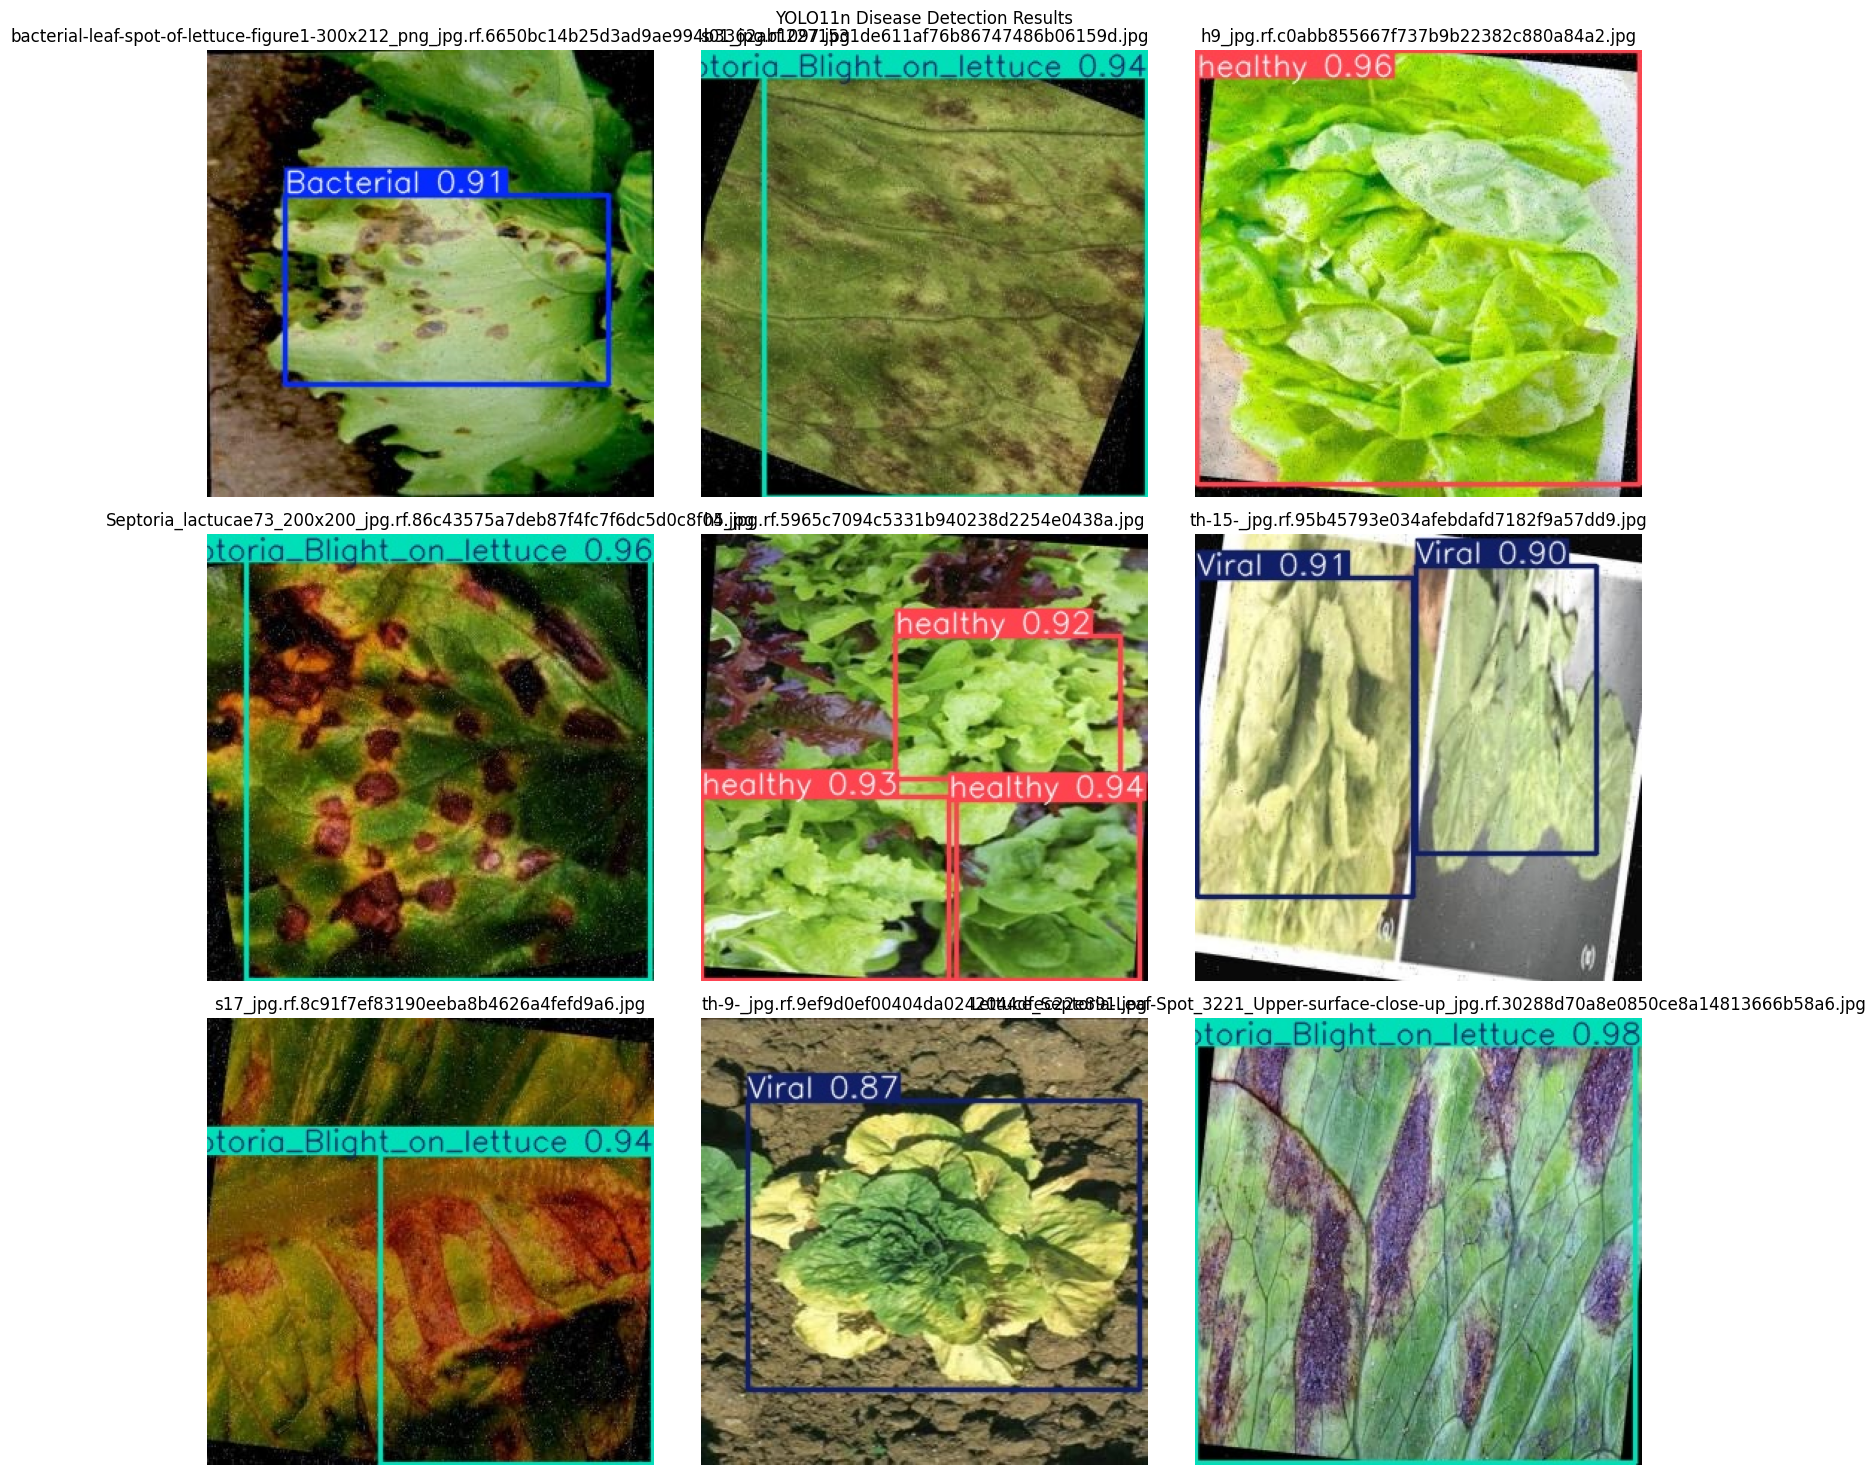

In [10]:
# Cell 6: Visual Inference on Test Data (Fixed Paths)
import os
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# 1. Tentukan Path yang Benar (Sesuai Cell 4)
weights_path = '/content/final_project/output/lettuce_yolo11_run/weights/best.pt'
inference_project_path = '/content/final_project/output/inference'
test_images_path = '/content/final_project/dataset/test/images'

# Fallback: jika folder test tidak ada, gunakan valid
if not os.path.exists(test_images_path):
    print("⚠️ Test folder not found, switching to Valid folder...")
    test_images_path = '/content/final_project/dataset/valid/images'

# 2. Cek apakah weights ada
if not os.path.exists(weights_path):
    raise FileNotFoundError(f"❌ Weights file tidak ditemukan di: {weights_path}\nPastikan proses training di Cell 4 selesai tanpa error.")

print(f"✅ Loading weights from: {weights_path}")
best_model = YOLO(weights_path)

# 3. Run Inference
print(f"🚀 Running inference on: {test_images_path}")
results = best_model.predict(
    source=test_images_path,
    conf=0.4,
    save=True,
    project=inference_project_path,  # Simpan ke folder /inference
    name='test_vis',               # Nama subfolder
    max_det=5,
    exist_ok=True,
    verbose=False
)

# 4. Plot 3x3 Grid
# Cari hasil prediksi (bisa .jpg atau .png)
pred_path_pattern = os.path.join(inference_project_path, 'test_vis', '*')
pred_files = glob.glob(pred_path_pattern + '.jpg') + glob.glob(pred_path_pattern + '.png')

print(f"Found {len(pred_files)} prediction images.")

if len(pred_files) > 0:
    plt.figure(figsize=(15, 15))
    # Ambil sampel maksimal 9 gambar
    num_samples = min(9, len(pred_files))

    for i, img_path in enumerate(random.sample(pred_files, num_samples)):
        plt.subplot(3, 3, i + 1)
        plt.imshow(Image.open(img_path))
        plt.axis('off')
        plt.title(os.path.basename(img_path))

    plt.suptitle("YOLO11n Disease Detection Results")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Tidak ada gambar hasil prediksi yang ditemukan.")

In [11]:
# Cell 7: Export to ONNX for Ryzen CPU (Fixed Path)
from ultralytics import YOLO
import os

# 1. Define Paths
weights_path = '/content/final_project/output/lettuce_yolo11_run/weights/best.pt'
export_path = '/content/final_project/output/lettuce_yolo11_run/weights/best.onnx'

# 2. Check Weights
if not os.path.exists(weights_path):
    raise FileNotFoundError(f"❌ Weights file tidak ditemukan di: {weights_path}")

print(f"📦 Loading model from: {weights_path}")
model = YOLO(weights_path)

# 3. Export
print("📦 Exporting model to ONNX...")
success = model.export(
    format='onnx',
    imgsz=640,
    opset=12,          # Broad compatibility
    simplify=True      # Optimize graph for faster inference
)

print(f"\n✅ Export success: {success}")
print(f"File saved at: {export_path}")

📦 Loading model from: /content/final_project/output/lettuce_yolo11_run/weights/best.pt
📦 Exporting model to ONNX...
Ultralytics 8.3.249 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 100 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/final_project/output/lettuce_yolo11_run/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 11, 8400) (5.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 10 packages in 203ms
Prepared 2 packages in 32ms
Installed 2 packages in 7ms
 + colorama==0.4.6
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: star

In [12]:
# Cell 8: FastAPI Implementation Snippet (COPY THIS)

fastapi_code = """
### SAVE THIS AS main.py ON YOUR LAPTOP ###

from fastapi import FastAPI, File, UploadFile
from ultralytics import YOLO
from PIL import Image
import io
import cv2
import numpy as np

app = FastAPI()

# PENTING: Pastikan file 'best.onnx' ada di satu folder dengan main.py ini
print("Loading ONNX model...")
# 'task=detect' wajib ada saat load ONNX di Ultralytics
model = YOLO("best.onnx", task="detect")

@app.post("/predict")
async def predict_disease(file: UploadFile = File(...)):
    # 1. Read Image
    contents = await file.read()
    image = Image.open(io.BytesIO(contents)).convert("RGB")

    # 2. Run Inference
    # imgsz=640 harus sama dengan saat training/export
    results = model.predict(image, imgsz=640, conf=0.4)

    # 3. Process Results
    detections = []
    for result in results:
        for box in result.boxes:
            detections.append({
                "class": result.names[int(box.cls)],
                "confidence": float(box.conf),
                "bbox": box.xyxy.tolist()[0]
            })

    return {"filename": file.filename, "predictions": detections}

# Cara Run di Terminal Laptop:
# uvicorn main:app --reload
"""

print(fastapi_code)


### SAVE THIS AS main.py ON YOUR LAPTOP ###

from fastapi import FastAPI, File, UploadFile
from ultralytics import YOLO
from PIL import Image
import io
import cv2
import numpy as np

app = FastAPI()

# PENTING: Pastikan file 'best.onnx' ada di satu folder dengan main.py ini
print("Loading ONNX model...")
# 'task=detect' wajib ada saat load ONNX di Ultralytics
model = YOLO("best.onnx", task="detect")

@app.post("/predict")
async def predict_disease(file: UploadFile = File(...)):
    # 1. Read Image
    contents = await file.read()
    image = Image.open(io.BytesIO(contents)).convert("RGB")
    
    # 2. Run Inference
    # imgsz=640 harus sama dengan saat training/export
    results = model.predict(image, imgsz=640, conf=0.4)
    
    # 3. Process Results
    detections = []
    for result in results:
        for box in result.boxes:
            detections.append({
                "class": result.names[int(box.cls)],
                "confidence": float(box.conf),
                "bbox"

In [13]:
# Cell 9: Zip and Download Results (Fixed Path)
import shutil
from google.colab import files
import os

# Folder yang akan di-zip (seluruh folder output project)
source_dir = '/content/final_project/output'
output_zip_name = '/content/Lettuce_Disease_YOLO11_Results' # Tanpa ekstensi .zip (otomatis ditambah)

print(f"🗄️ Zipping folder: {source_dir}...")

# Cek isi folder sebelum zip untuk memastikan
print("Isi folder yang akan di-zip:")
print(os.listdir(source_dir))

shutil.make_archive(output_zip_name, 'zip', source_dir)

full_zip_path = output_zip_name + '.zip'
print(f"✅ Zip file created at: {full_zip_path}")

# Download
print("Starting download...")
files.download(full_zip_path)

🗄️ Zipping folder: /content/final_project/output...
Isi folder yang akan di-zip:
['evaluation', 'lettuce_yolo11_run', 'plots', 'inference', 'checkpoints', 'logs']
✅ Zip file created at: /content/Lettuce_Disease_YOLO11_Results.zip
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Cell 10: Benchmark Performa (PyTorch vs ONNX)
import time
import numpy as np
import torch
from ultralytics import YOLO
import os

# 1. Path Model
weights_pt = '/content/final_project/output/lettuce_yolo11_run/weights/best.pt'
weights_onnx = '/content/final_project/output/lettuce_yolo11_run/weights/best.onnx'

# 2. Ambil 1 gambar contoh dari dataset validasi
test_img_dir = '/content/final_project/dataset/valid/images'
test_img_path = os.path.join(test_img_dir, os.listdir(test_img_dir)[0])

# 3. Fungsi Benchmark
def benchmark(model_path, device='cpu', iterations=50):
    model = YOLO(model_path, task='detect')

    # Warm-up (pemanasan agar hasil akurat)
    for _ in range(5):
        model.predict(test_img_path, device=device, imgsz=640, verbose=False)

    # Start Timing
    start_time = time.time()
    for _ in range(iterations):
        model.predict(test_img_path, device=device, imgsz=640, verbose=False)
    end_time = time.time()

    avg_time = ((end_time - start_time) / iterations) * 1000 # konversi ke ms
    return avg_time

print(f"📊 Menjalankan Benchmark pada CPU (Ryzen Simulation)...")
print(f"Gambar uji: {os.path.basename(test_img_path)}")
print("-" * 50)

# Run Benchmark untuk PT
time_pt = benchmark(weights_pt, device='cpu')
print(f"🚀 PyTorch (.pt)  - Rata-rata: {time_pt:.2f} ms / gambar")

# Run Benchmark untuk ONNX
time_onnx = benchmark(weights_onnx, device='cpu')
print(f"🚀 ONNX (.onnx)   - Rata-rata: {time_onnx:.2f} ms / gambar")

# Hitung Peningkatan
pemanfaatan = ((time_pt - time_onnx) / time_pt) * 100
print("-" * 50)
print(f"✅ KESIMPULAN: ONNX {pemanfaatan:.1f}% lebih cepat daripada PyTorch di CPU!")

📊 Menjalankan Benchmark pada CPU (Ryzen Simulation)...
Gambar uji: ba18_jpg.rf.17d64d4cc04b0e974ff84c1b081f40ce.jpg
--------------------------------------------------
🚀 PyTorch (.pt)  - Rata-rata: 140.86 ms / gambar
Loading /content/final_project/output/lettuce_yolo11_run/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 9 packages in 150ms
Prepared 1 package in 261ms
Installed 1 package in 44ms
 + onnxruntime==1.23.2

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Using ONNX Runtime 1.23.2 with CPUExecutionProvider
🚀 ONNX (.onnx)   - Rata-rata: 109.82 ms / gambar
--------------------------------------------------
✅ KESIMPULAN: ONNX 22.0% lebih cepat daripada PyTorch di CPU!
